# Projet Machine Learning : Analyse et Modélisation d'un Jeu de Données Médical
**Objectif** : Analyser les facteurs influençant le risque et la présence du diabète, et construire des modèles prédictifs.

## Partie 1 : Lecture des données

In [1]:
# 1. Import des bibliothèques
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LinearRegression
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import (
    classification_report, accuracy_score, confusion_matrix,
    silhouette_score, davies_bouldin_score,
    r2_score, mean_squared_error, mean_absolute_error
)
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.stats import pearsonr

import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

C:\Users\Solene_NDS\AppData\Roaming\Python\Python310\site-packages\pandas\core\arrays\masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [2]:
# 2. Chargement des données
df = pd.read_csv('patients_synthetic_1000.csv')

# 3. Aperçu des données
print('_Aperçu des premières lignes_ ')
display(df.head())
print('\n_Informations générales_ ')
df.info()

_Aperçu des premières lignes_ 


,patient_id,age,sex,smoker,physical_activity,diet_quality,bmi,systolic_bp,diastolic_bp,glucose_fasting,hba1c,cholesterol_total,hdl_cholesterol,ldl_cholesterol,triglycerides,diabetes,risk_category
0,1,55,Female,Yes,Medium,Poor,33.7,129,85,113.2,4.75,226,47,129,234,No,Moderate
1,2,32,Male,Yes,Medium,Poor,28.9,99,62,98.2,4.69,177,25,135,109,No,Low
2,3,63,Male,No,Low,Average,21.3,104,72,93.6,5.03,167,58,75,116,No,Low
3,4,66,Male,No,Low,Poor,31.3,131,87,114.2,5.37,220,50,150,105,No,Moderate
4,5,18,Male,No,Medium,Good,27.4,95,61,88.3,4.98,142,63,55,172,No,Low



_Informations générales_ 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 17 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   patient_id         1000 non-null   int64  
 1   age                1000 non-null   int64  
 2   sex                1000 non-null   object 
 3   smoker             1000 non-null   object 
 4   physical_activity  1000 non-null   object 
 5   diet_quality       1000 non-null   object 
 6   bmi                1000 non-null   float64
 7   systolic_bp        1000 non-null   int64  
 8   diastolic_bp       1000 non-null   int64  
 9   glucose_fasting    1000 non-null   float64
 10  hba1c              1000 non-null   float64
 11  cholesterol_total  1000 non-null   int64  
 12  hdl_cholesterol    1000 non-null   int64  
 13  ldl_cholesterol    1000 non-null   int64  
 14  triglycerides      1000 non-null   int64  
 15  diabetes           1000 non-null   object 
 16

## Partie 2 : Analyse des données

### 2.1 Description du jeu de données

In [3]:
print(f'Nombre de lignes    : {df.shape[0]}')
print(f'Nombre de colonnes  : {df.shape[1]}')
print()

# Identification des types de variables
continuous_vars = ['age', 'bmi', 'systolic_bp', 'diastolic_bp',
                   'glucose_fasting', 'hba1c', 'cholesterol_total',
                   'hdl_cholesterol', 'ldl_cholesterol', 'triglycerides']

categorical_vars = ['sex', 'smoker', 'physical_activity', 'diet_quality',
                    'diabetes', 'risk_category']

print('Variables continues  :', continuous_vars)
print('Variables catégorielles :', categorical_vars)
print()
print('_ Statistiques descriptives (variables continues) _')
display(df[continuous_vars].describe().round(2))

Nombre de lignes    : 1000
Nombre de colonnes  : 17

Variables continues  : ['age', 'bmi', 'systolic_bp', 'diastolic_bp', 'glucose_fasting', 'hba1c', 'cholesterol_total', 'hdl_cholesterol', 'ldl_cholesterol', 'triglycerides']
Variables catégorielles : ['sex', 'smoker', 'physical_activity', 'diet_quality', 'diabetes', 'risk_category']

_ Statistiques descriptives (variables continues) _


,age,bmi,systolic_bp,diastolic_bp,glucose_fasting,hba1c,cholesterol_total,hdl_cholesterol,ldl_cholesterol,triglycerides
count,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00
mean,49.68,28.62,117.69,73.69,101.68,4.85,193.67,51.22,114.73,140.93
std,16.18,5.22,13.65,8.21,14.62,0.30,37.47,12.82,40.66,49.95
min,18.00,16.00,85.00,50.00,65.00,3.80,110.00,25.00,40.00,40.00
25%,38.00,25.10,108.00,68.00,92.05,4.65,168.00,42.00,85.00,107.00
50%,50.00,28.60,118.00,73.00,102.20,4.85,191.00,52.00,111.50,141.50
75%,60.00,32.22,127.00,79.00,111.43,5.06,217.00,60.00,142.00,174.00
max,90.00,44.20,164.00,101.00,145.50,5.73,334.00,98.00,284.00,282.00


### 2.2 Nettoyage et exploration des données

In [4]:
# Détection des valeurs manquantes
print('_ Valeurs manquantes _')
missing = df.isnull().sum()
print(missing[missing > 0] if missing.sum() > 0 else 'Aucune valeur manquante ')

# Détection des doublons
print(f'\nNombre de doublons : {df.duplicated().sum()}')

_ Valeurs manquantes _
Aucune valeur manquante 

Nombre de doublons : 0


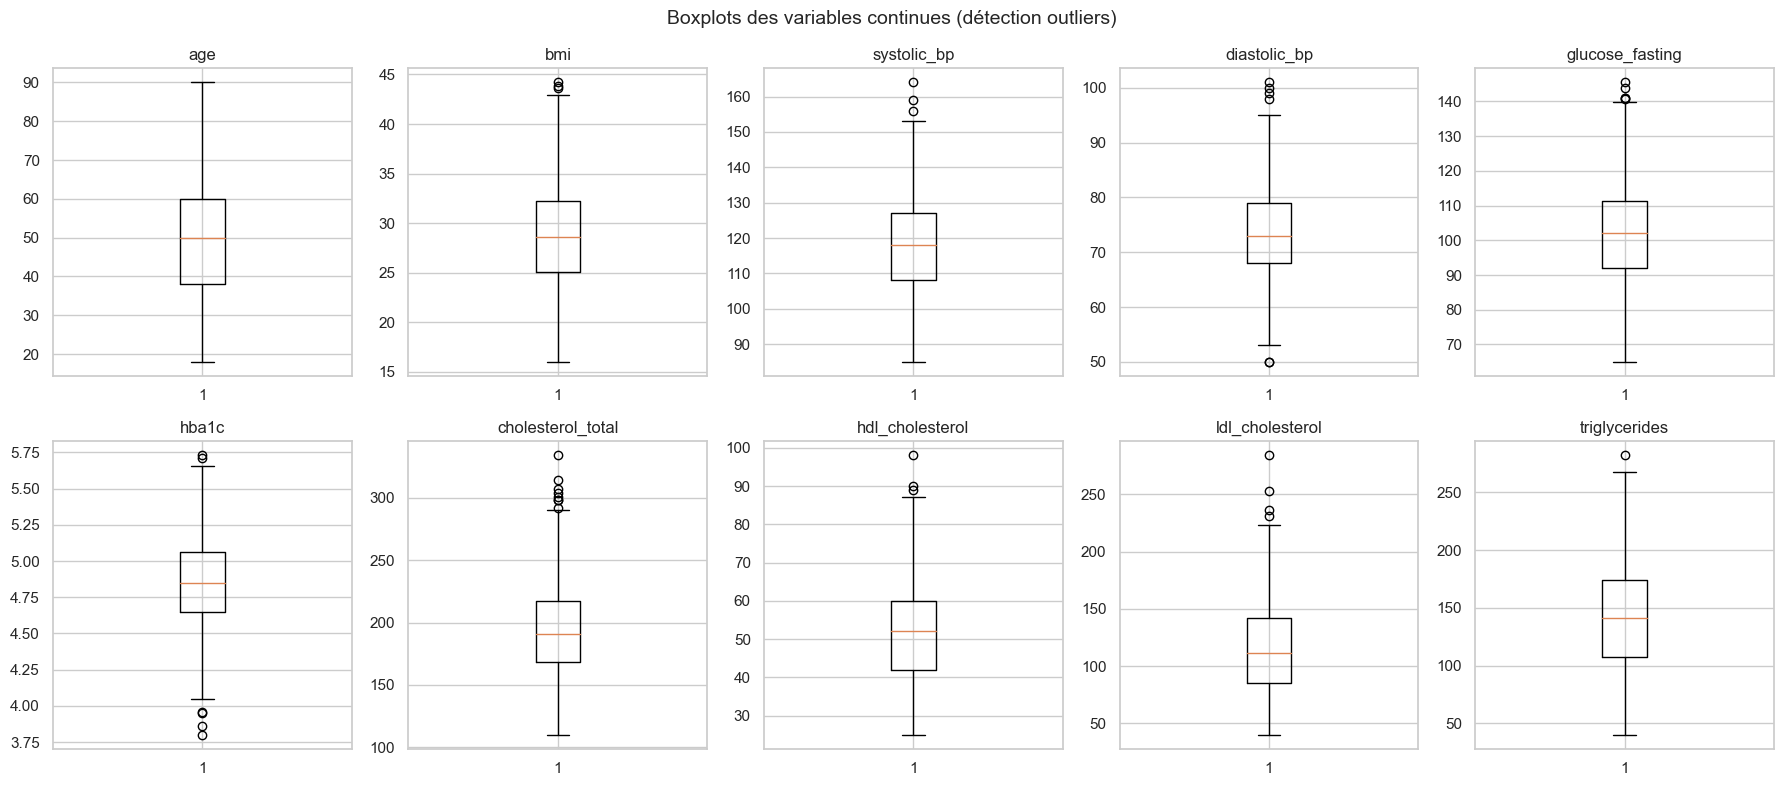

In [5]:
# Détection des outliers avec boxplots
fig, axes = plt.subplots(2, 5, figsize=(18, 8))
axes = axes.flatten()

for i, col in enumerate(continuous_vars):
    axes[i].boxplot(df[col].dropna())
    axes[i].set_title(col)
    axes[i].set_xlabel('')

plt.suptitle('Boxplots des variables continues (détection outliers)', fontsize=14)
plt.tight_layout()
plt.show()

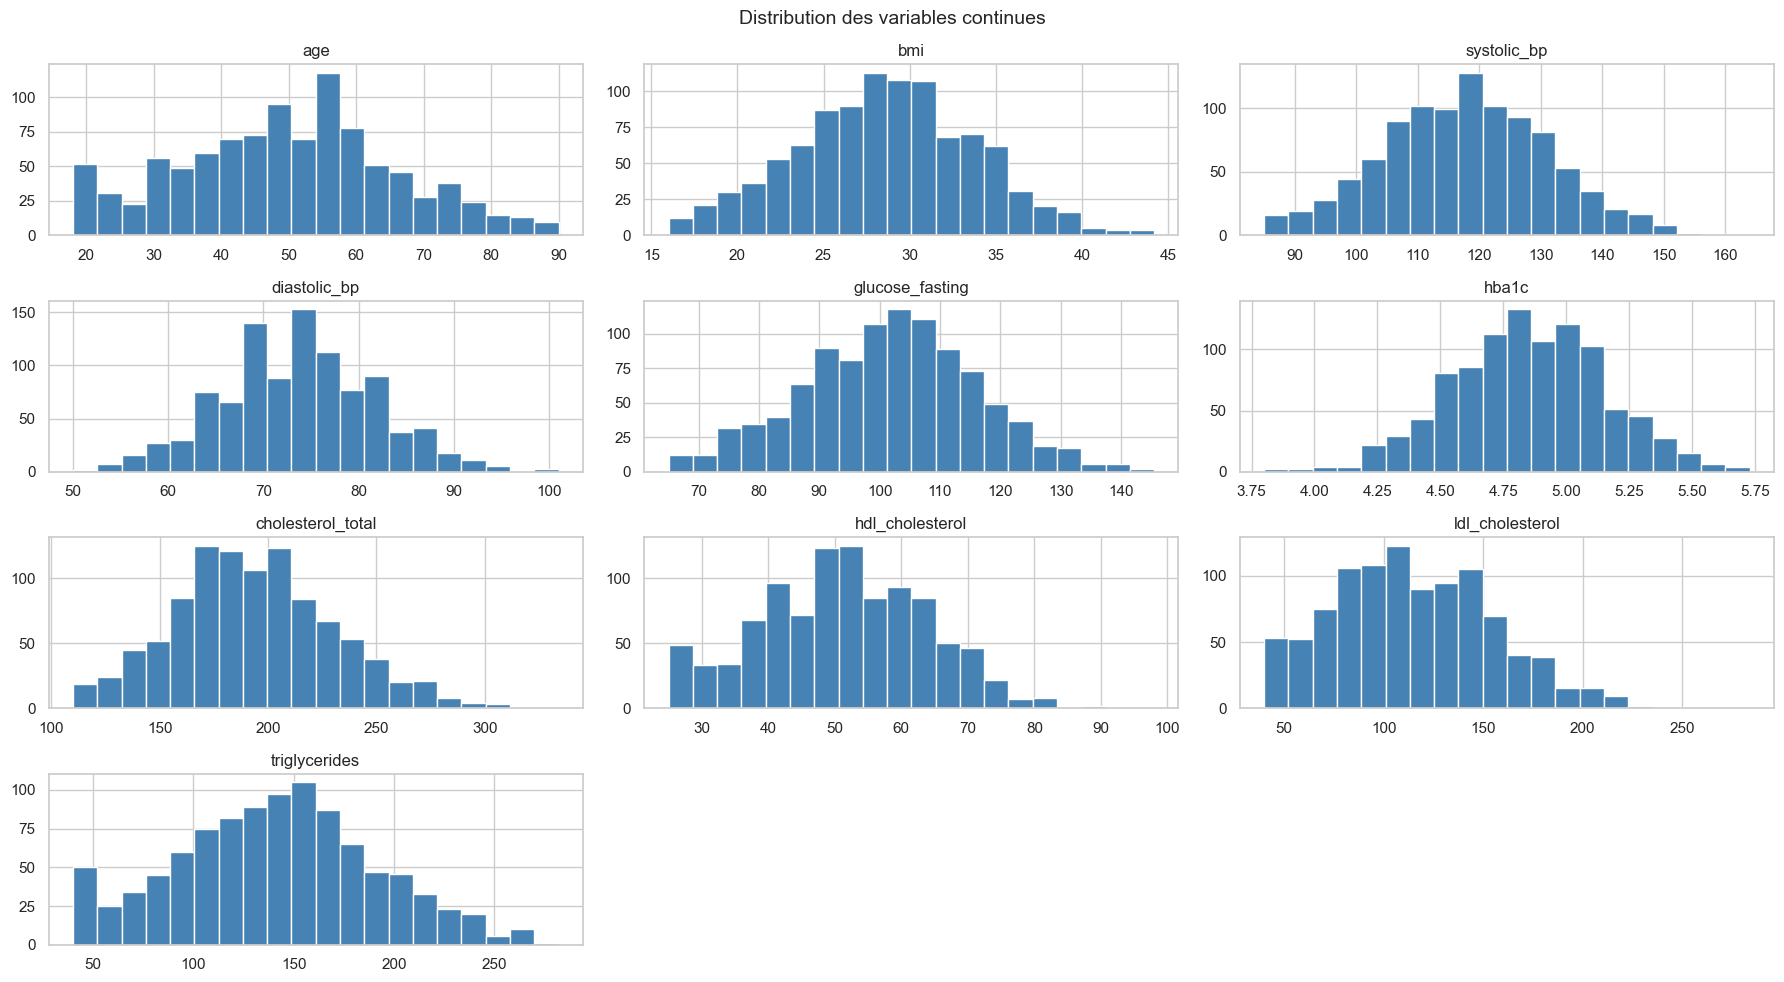

In [6]:
# Histogrammes des variables continues
df[continuous_vars].hist(bins=20, figsize=(18, 10), color='steelblue', edgecolor='white')
plt.suptitle('Distribution des variables continues', fontsize=14)
plt.tight_layout()
plt.show()

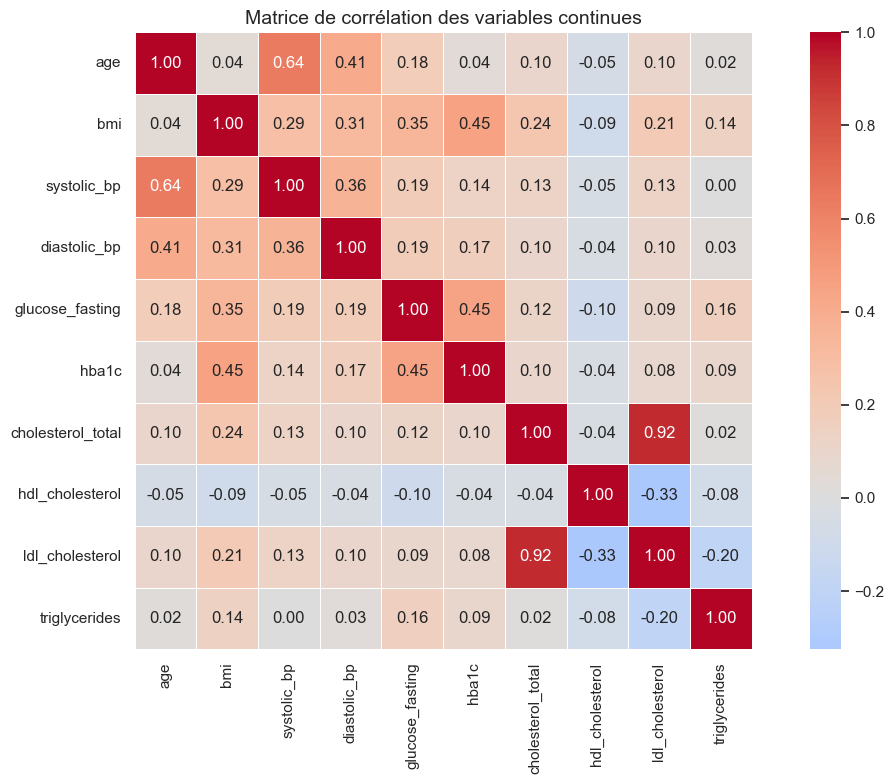

In [7]:
# Matrice de corrélation
plt.figure(figsize=(12, 8))
corr_matrix = df[continuous_vars].corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=0.5)
plt.title('Matrice de corrélation des variables continues', fontsize=14)
plt.tight_layout()
plt.show()

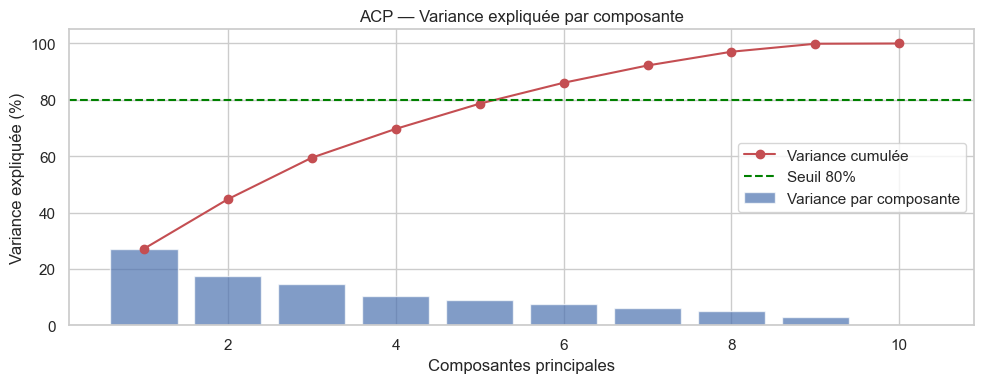

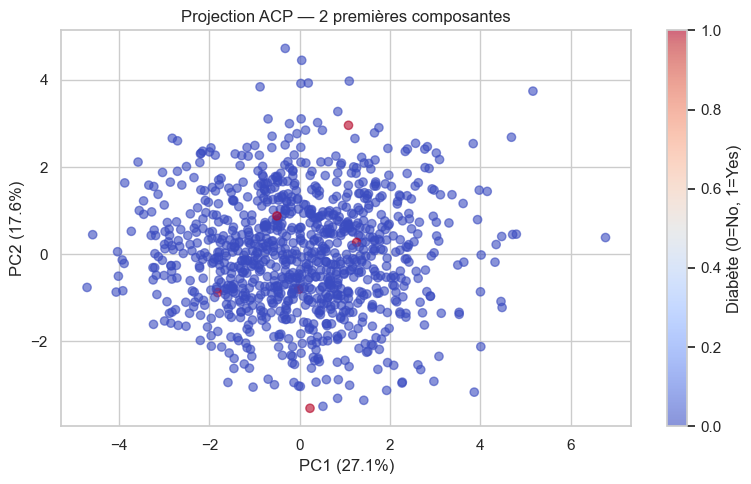

PC1 + PC2 expliquent 44.7% de la variance totale


In [8]:
# Réduction dimensionnelle : ACP (PCA)
from sklearn.decomposition import PCA

# Normalisation des variables continues
X_pca = df[continuous_vars].copy()
scaler_pca = StandardScaler()
X_pca_scaled = scaler_pca.fit_transform(X_pca)

# Application de la PCA
pca = PCA()
pca.fit(X_pca_scaled)

# Variance expliquée
explained_variance = pca.explained_variance_ratio_ * 100
cumulative_variance = np.cumsum(explained_variance)

plt.figure(figsize=(10, 4))
plt.bar(range(1, len(explained_variance)+1), explained_variance, alpha=0.7, label='Variance par composante')
plt.plot(range(1, len(explained_variance)+1), cumulative_variance, 'ro-', label='Variance cumulée')
plt.axhline(80, color='green', linestyle='--', label='Seuil 80%')
plt.xlabel('Composantes principales')
plt.ylabel('Variance expliquée (%)')
plt.title('ACP — Variance expliquée par composante')
plt.legend()
plt.tight_layout()
plt.show()

# Projection sur les 2 premières composantes
pca_2d = PCA(n_components=2)
X_proj = pca_2d.fit_transform(X_pca_scaled)

plt.figure(figsize=(8, 5))
scatter = plt.scatter(X_proj[:, 0], X_proj[:, 1],
                      c=LabelEncoder().fit_transform(df['diabetes']),
                      cmap='coolwarm', alpha=0.6)
plt.colorbar(scatter, label='Diabète (0=No, 1=Yes)')
plt.xlabel(f'PC1 ({explained_variance[0]:.1f}%)')
plt.ylabel(f'PC2 ({explained_variance[1]:.1f}%)')
plt.title('Projection ACP — 2 premières composantes')
plt.tight_layout()
plt.show()

print(f'PC1 + PC2 expliquent {cumulative_variance[1]:.1f}% de la variance totale')

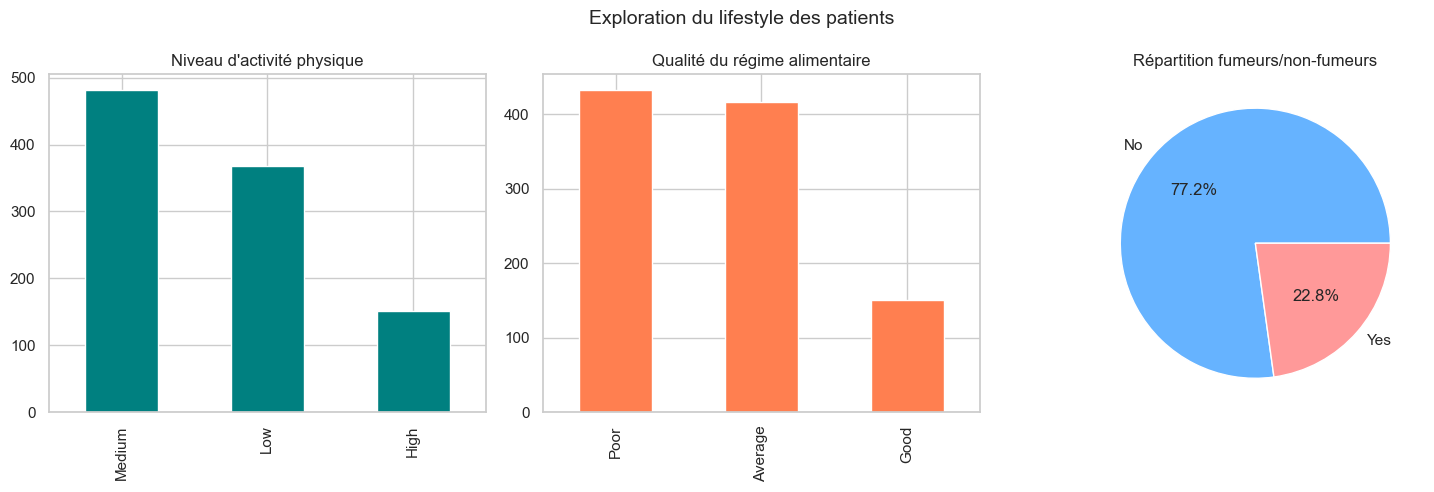

In [9]:
# Visualisation du lifestyle des patients
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Activité physique
df['physical_activity'].value_counts().plot(kind='bar', ax=axes[0], color='teal')
axes[0].set_title("Niveau d'activité physique")
axes[0].set_xlabel('')

# Qualité du régime
df['diet_quality'].value_counts().plot(kind='bar', ax=axes[1], color='coral')
axes[1].set_title('Qualité du régime alimentaire')
axes[1].set_xlabel('')

# Tabagisme
df['smoker'].value_counts().plot(kind='pie', ax=axes[2], autopct='%1.1f%%',
                                  colors=['#66b3ff','#ff9999'])
axes[2].set_title('Répartition fumeurs/non-fumeurs')
axes[2].set_ylabel('')

plt.suptitle('Exploration du lifestyle des patients', fontsize=14)
plt.tight_layout()
plt.show()

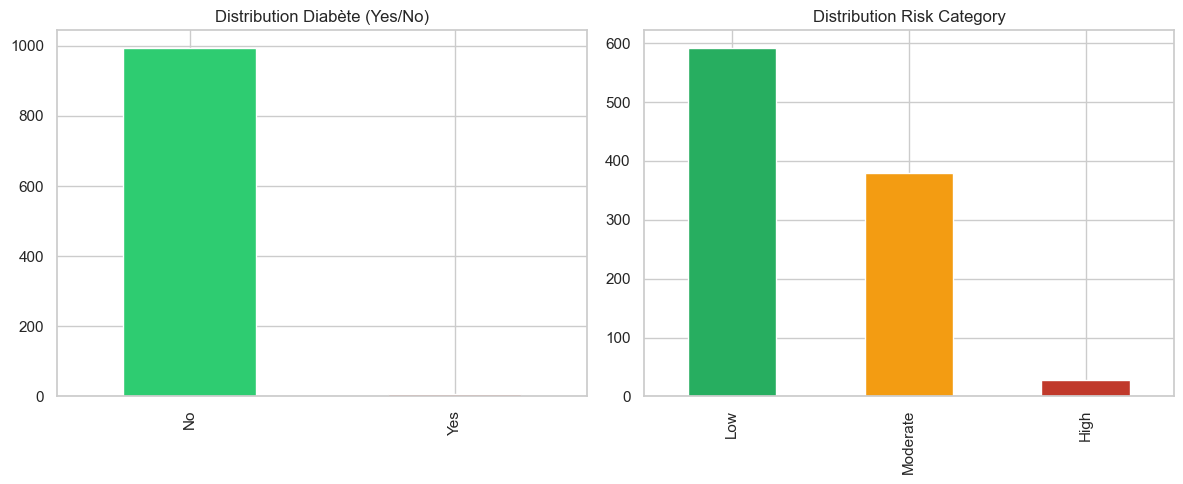

In [10]:
# Distribution du diabète et de la catégorie de risque
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

df['diabetes'].value_counts().plot(kind='bar', ax=axes[0], color=['#2ecc71', '#e74c3c'])
axes[0].set_title('Distribution Diabète (Yes/No)')
axes[0].set_xlabel('')

df['risk_category'].value_counts().plot(kind='bar', ax=axes[1],
                                         color=['#27ae60', '#f39c12', '#c0392b'])
axes[1].set_title('Distribution Risk Category')
axes[1].set_xlabel('')

plt.tight_layout()
plt.show()

### 2.3 Clustering

In [11]:
# Préparation des données pour le clustering
cluster_vars = ['bmi', 'systolic_bp', 'diastolic_bp',
                'glucose_fasting', 'hba1c', 'cholesterol_total',
                'hdl_cholesterol', 'ldl_cholesterol', 'triglycerides']

X_clust = df[cluster_vars].copy()
scaler = StandardScaler()
X_clust_scaled = scaler.fit_transform(X_clust)

print('Données normalisées pour le clustering :', X_clust_scaled.shape)

Données normalisées pour le clustering : (1000, 9)


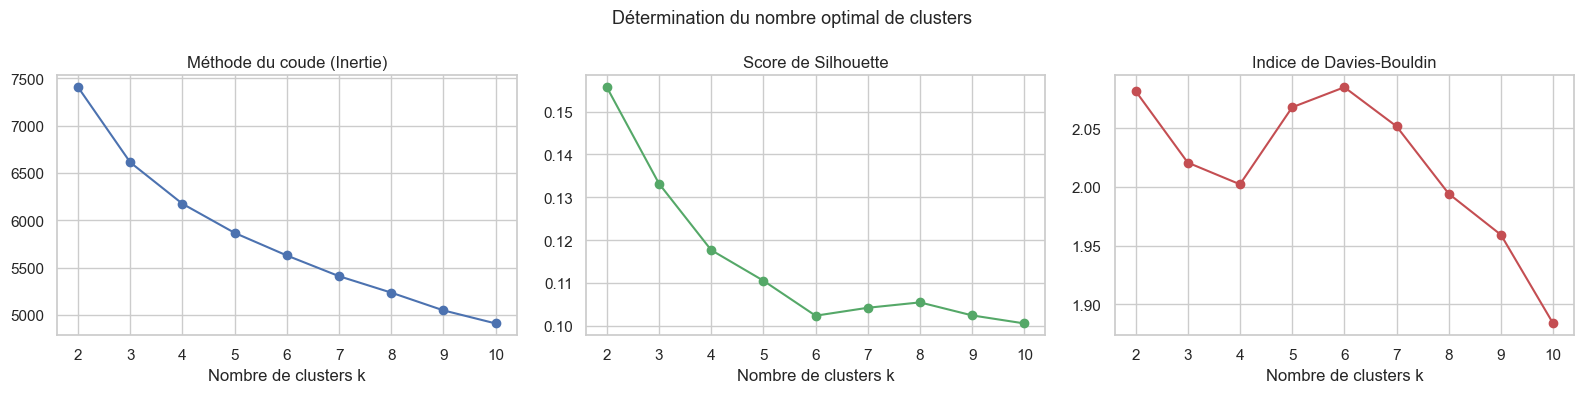


Nombre optimal de clusters (silhouette max) : k = 2


In [12]:
#  KMeans : Méthode du coude 
inertias = []
silhouettes = []
davies = []
K_range = range(2, 11)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_clust_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_clust_scaled, labels))
    davies.append(davies_bouldin_score(X_clust_scaled, labels))

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].plot(K_range, inertias, 'bo-')
axes[0].set_title('Méthode du coude (Inertie)')
axes[0].set_xlabel('Nombre de clusters k')

axes[1].plot(K_range, silhouettes, 'go-')
axes[1].set_title('Score de Silhouette')
axes[1].set_xlabel('Nombre de clusters k')

axes[2].plot(K_range, davies, 'ro-')
axes[2].set_title('Indice de Davies-Bouldin')
axes[2].set_xlabel('Nombre de clusters k')

plt.suptitle('Détermination du nombre optimal de clusters', fontsize=13)
plt.tight_layout()
plt.show()

best_k = K_range[silhouettes.index(max(silhouettes))]
print(f'\nNombre optimal de clusters (silhouette max) : k = {best_k}')

KMeans (k=2) — Silhouette: 0.156 | Davies-Bouldin: 2.082


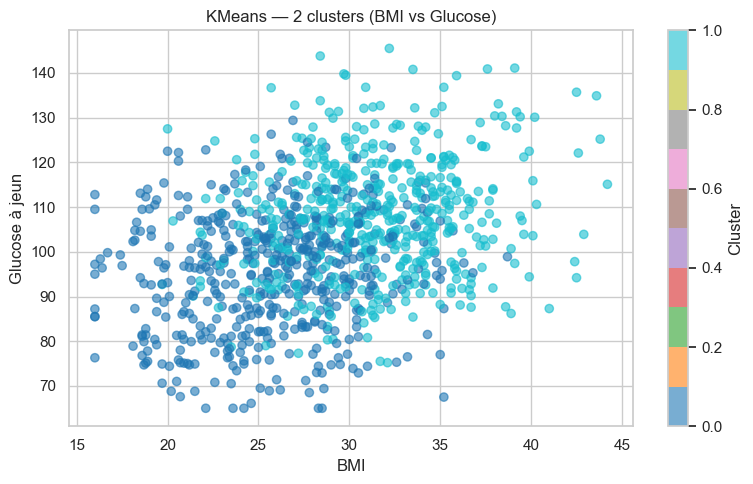


_ Profil moyen par cluster KMeans _


,bmi,systolic_bp,diastolic_bp,glucose_fasting,hba1c,cholesterol_total,hdl_cholesterol,ldl_cholesterol,triglycerides
cluster_kmeans,,,,,,,,,
0,25.75,112.71,70.37,94.98,4.72,174.28,54.56,92.98,136.07
1,31.43,122.60,76.96,108.27,4.98,212.75,47.93,136.13,145.71


In [13]:
# KMeans avec k optimal
kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
df['cluster_kmeans'] = kmeans.fit_predict(X_clust_scaled)

sil = silhouette_score(X_clust_scaled, df['cluster_kmeans'])
db  = davies_bouldin_score(X_clust_scaled, df['cluster_kmeans'])
print(f'KMeans (k={best_k}) — Silhouette: {sil:.3f} | Davies-Bouldin: {db:.3f}')

# Visualisation des clusters (BMI vs Glucose)
plt.figure(figsize=(8, 5))
scatter = plt.scatter(df['bmi'], df['glucose_fasting'],
                      c=df['cluster_kmeans'], cmap='tab10', alpha=0.6)
plt.colorbar(scatter, label='Cluster')
plt.xlabel('BMI')
plt.ylabel('Glucose à jeun')
plt.title(f'KMeans — {best_k} clusters (BMI vs Glucose)')
plt.tight_layout()
plt.show()

# Profil moyen par cluster
print('\n_ Profil moyen par cluster KMeans _')
display(df.groupby('cluster_kmeans')[cluster_vars].mean().round(2))

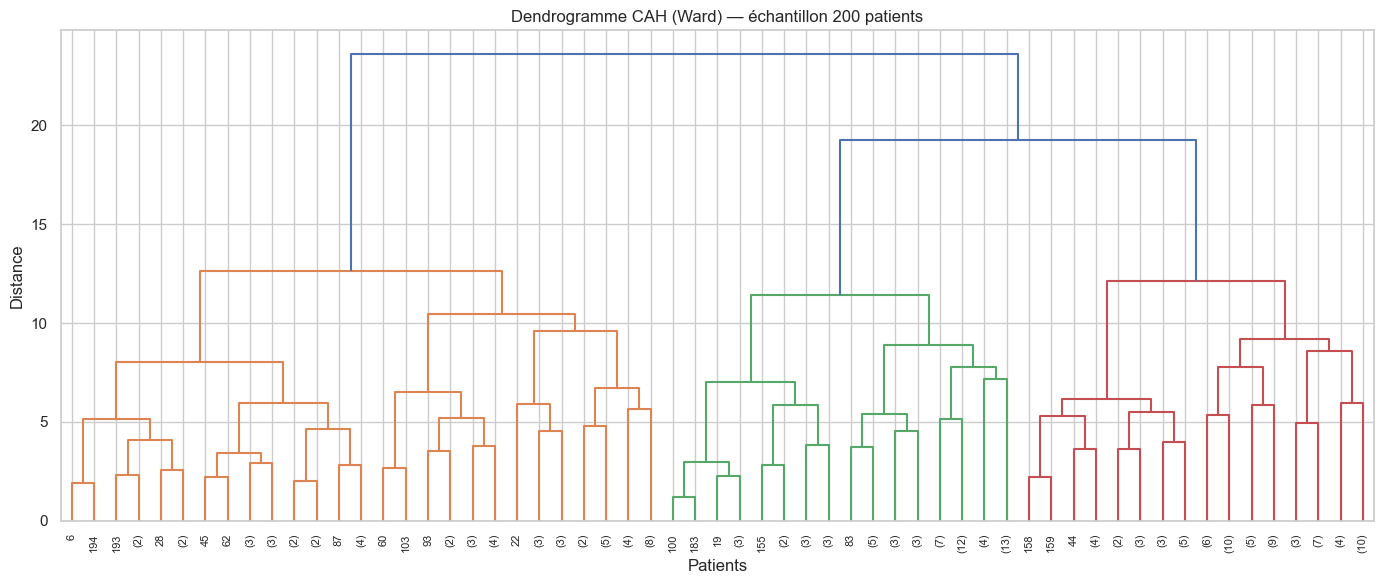

In [14]:
#  Classification Ascendante Hiérarchique (CAH) 
# On prend un échantillon de 200 patients pour la lisibilité du dendrogramme
sample_idx = np.random.choice(len(X_clust_scaled), 200, replace=False)
X_sample = X_clust_scaled[sample_idx]

linked = linkage(X_sample, method='ward')

plt.figure(figsize=(14, 6))
dendrogram(linked, truncate_mode='level', p=5,
           leaf_rotation=90, leaf_font_size=8)
plt.title('Dendrogramme CAH (Ward) — échantillon 200 patients')
plt.xlabel('Patients')
plt.ylabel('Distance')
plt.tight_layout()
plt.show()

In [15]:
# CAH sur tout le dataset
cah = AgglomerativeClustering(n_clusters=best_k, linkage='ward')
df['cluster_cah'] = cah.fit_predict(X_clust_scaled)

sil_cah = silhouette_score(X_clust_scaled, df['cluster_cah'])
db_cah  = davies_bouldin_score(X_clust_scaled, df['cluster_cah'])
print(f'CAH (k={best_k}) — Silhouette: {sil_cah:.3f} | Davies-Bouldin: {db_cah:.3f}')

# Comparaison KMeans vs CAH
print('\n_ Comparaison des métriques _')
print(f'{"Méthode":<10} {"Silhouette":>12} {"Davies-Bouldin":>16}')
print(f'{"KMeans":<10} {sil:>12.3f} {db:>16.3f}')
print(f'{"CAH":<10} {sil_cah:>12.3f} {db_cah:>16.3f}')

CAH (k=2) — Silhouette: 0.123 | Davies-Bouldin: 2.418

_ Comparaison des métriques _
Méthode      Silhouette   Davies-Bouldin
KMeans            0.156            2.082
CAH               0.123            2.418


### 2.4 Régression Linéaire

_ Régression simple : BMI -> Glucose _
Coefficient (pente) : 0.9501
Intercept           : 74.9334
R²                  : 0.1201
MAE                 : 10.6063
RMSE                : 13.0835


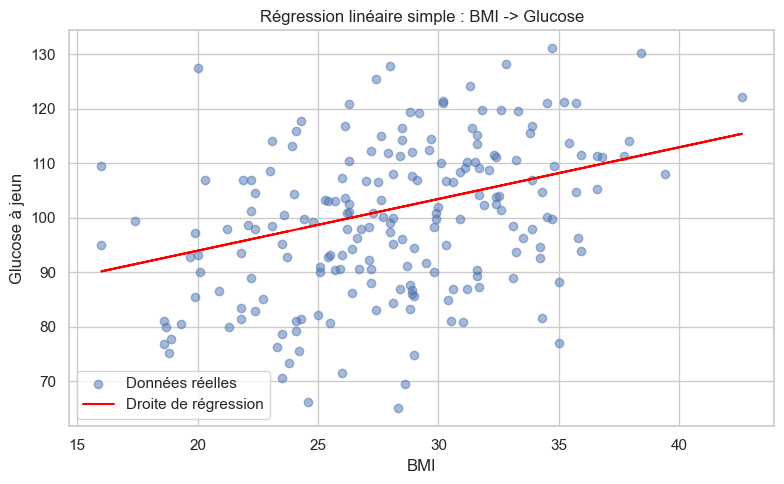

In [16]:
#  Régression linéaire simple : BMI -> Glucose 
X_simple = df[['bmi']]
y_glucose = df['glucose_fasting']

X_tr, X_te, y_tr, y_te = train_test_split(X_simple, y_glucose,
                                            test_size=0.2, random_state=42)

reg_simple = LinearRegression()
reg_simple.fit(X_tr, y_tr)
y_pred_simple = reg_simple.predict(X_te)

print('_ Régression simple : BMI -> Glucose _')
print(f'Coefficient (pente) : {reg_simple.coef_[0]:.4f}')
print(f'Intercept           : {reg_simple.intercept_:.4f}')
print(f'R²                  : {r2_score(y_te, y_pred_simple):.4f}')
print(f'MAE                 : {mean_absolute_error(y_te, y_pred_simple):.4f}')
print(f'RMSE                : {np.sqrt(mean_squared_error(y_te, y_pred_simple)):.4f}')

# Visualisation
plt.figure(figsize=(8, 5))
plt.scatter(X_te, y_te, alpha=0.5, label='Données réelles')
plt.plot(X_te, y_pred_simple, color='red', label='Droite de régression')
plt.xlabel('BMI')
plt.ylabel('Glucose à jeun')
plt.title('Régression linéaire simple : BMI -> Glucose')
plt.legend()
plt.tight_layout()
plt.show()

_ Régression multiple : prédire HbA1c
  bmi                  : 0.0184
  glucose_fasting      : 0.0075
  age                  : -0.0010
  systolic_bp          : 0.0001
  triglycerides        : -0.0001
Intercept : 3.6136
R²        : 0.3232
MAE       : 0.1877
RMSE      : 0.2404


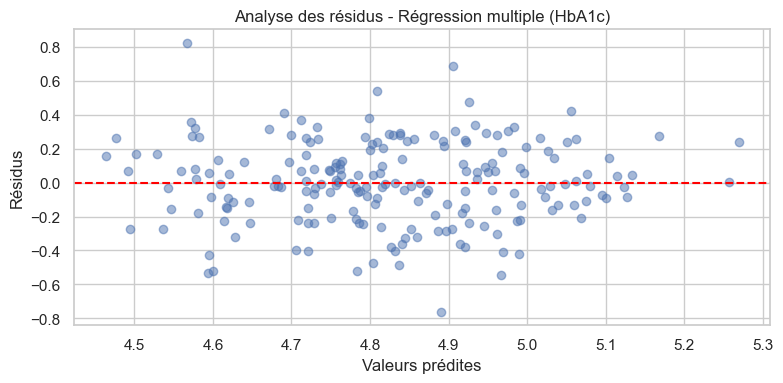

In [17]:
# Régression linéaire multiple : prédire HbA1c
features_multi = ['bmi', 'glucose_fasting', 'age', 'systolic_bp', 'triglycerides']
X_multi = df[features_multi]
y_hba1c = df['hba1c']

X_tr2, X_te2, y_tr2, y_te2 = train_test_split(X_multi, y_hba1c,
                                               test_size=0.2, random_state=42)

reg_multi = LinearRegression()
reg_multi.fit(X_tr2, y_tr2)
y_pred_multi = reg_multi.predict(X_te2)

print('_ Régression multiple : prédire HbA1c')
for feat, coef in zip(features_multi, reg_multi.coef_):
    print(f'  {feat:<20} : {coef:.4f}')
print(f'Intercept : {reg_multi.intercept_:.4f}')
print(f'R²        : {r2_score(y_te2, y_pred_multi):.4f}')
print(f'MAE       : {mean_absolute_error(y_te2, y_pred_multi):.4f}')
print(f'RMSE      : {np.sqrt(mean_squared_error(y_te2, y_pred_multi)):.4f}')

# Résidus
residuals = y_te2 - y_pred_multi
plt.figure(figsize=(8, 4))
plt.scatter(y_pred_multi, residuals, alpha=0.5)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Valeurs prédites')
plt.ylabel('Résidus')
plt.title('Analyse des résidus - Régression multiple (HbA1c)')
plt.tight_layout()
plt.show()

### 2.5 Classification avec KNN

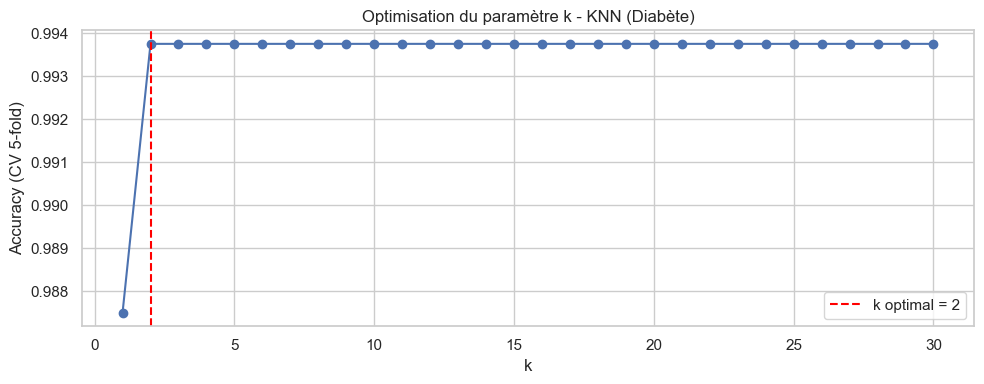

k optimal : 2 (accuracy CV = 0.9938)


In [18]:
#  Classification binaire : prédire diabetes
features_clf = ['age', 'bmi', 'glucose_fasting', 'hba1c',
                'systolic_bp', 'diastolic_bp', 'cholesterol_total',
                'hdl_cholesterol', 'ldl_cholesterol', 'triglycerides']

X_clf = df[features_clf].copy()
y_clf = LabelEncoder().fit_transform(df['diabetes'])  # No=0, Yes=1

scaler_clf = StandardScaler()
X_clf_scaled = scaler_clf.fit_transform(X_clf)

X_tr3, X_te3, y_tr3, y_te3 = train_test_split(X_clf_scaled, y_clf,
                                               test_size=0.2, random_state=42)

# Optimisation de k
k_scores = []
for k in range(1, 31):
    knn = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(knn, X_tr3, y_tr3, cv=5, scoring='accuracy')
    k_scores.append(scores.mean())

best_k_clf = np.argmax(k_scores) + 1

plt.figure(figsize=(10, 4))
plt.plot(range(1, 31), k_scores, 'bo-')
plt.axvline(best_k_clf, color='red', linestyle='--', label=f'k optimal = {best_k_clf}')
plt.xlabel('k')
plt.ylabel('Accuracy (CV 5-fold)')
plt.title('Optimisation du paramètre k - KNN (Diabète)')
plt.legend()
plt.tight_layout()
plt.show()

print(f'k optimal : {best_k_clf} (accuracy CV = {k_scores[best_k_clf-1]:.4f})')

- KNN (k=2) - Classification Diabète (Yes/No)- 
              precision    recall  f1-score   support

          No       0.99      1.00      1.00       199
         Yes       0.00      0.00      0.00         1

    accuracy                           0.99       200
   macro avg       0.50      0.50      0.50       200
weighted avg       0.99      0.99      0.99       200



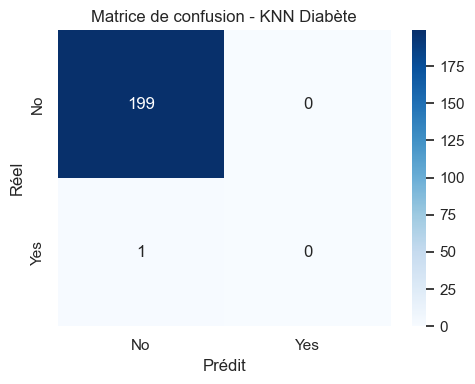

In [19]:
# KNN final — classification binaire
knn_final = KNeighborsClassifier(n_neighbors=best_k_clf)
knn_final.fit(X_tr3, y_tr3)
y_pred_clf = knn_final.predict(X_te3)

print(f'- KNN (k={best_k_clf}) - Classification Diabète (Yes/No)- ')
print(classification_report(y_te3, y_pred_clf, target_names=['No', 'Yes']))

# Matrice de confusion
cm = confusion_matrix(y_te3, y_pred_clf)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No', 'Yes'], yticklabels=['No', 'Yes'])
plt.title('Matrice de confusion - KNN Diabète')
plt.ylabel('Réel')
plt.xlabel('Prédit')
plt.tight_layout()
plt.show()

- KNN (k=20) - Classification Risk Category -
              precision    recall  f1-score   support

        High       0.00      0.00      0.00         4
         Low       0.84      0.94      0.89       119
    Moderate       0.84      0.73      0.78        77

    accuracy                           0.84       200
   macro avg       0.56      0.56      0.56       200
weighted avg       0.82      0.84      0.83       200



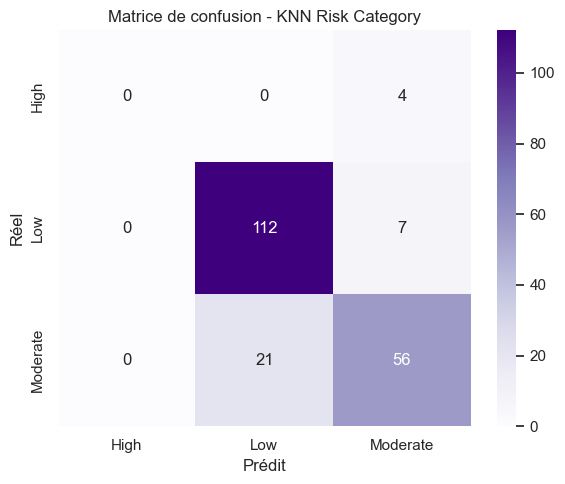

In [20]:
#  Classification multiclasse : prédire risk_category 
le_risk = LabelEncoder()
y_risk = le_risk.fit_transform(df['risk_category'])

X_tr4, X_te4, y_tr4, y_te4 = train_test_split(X_clf_scaled, y_risk,
                                               test_size=0.2, random_state=42)

# Optimisation de k pour multiclasse
k_scores_mc = []
for k in range(1, 31):
    knn = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(knn, X_tr4, y_tr4, cv=5, scoring='accuracy')
    k_scores_mc.append(scores.mean())

best_k_mc = np.argmax(k_scores_mc) + 1

knn_mc = KNeighborsClassifier(n_neighbors=best_k_mc)
knn_mc.fit(X_tr4, y_tr4)
y_pred_mc = knn_mc.predict(X_te4)

print(f'- KNN (k={best_k_mc}) - Classification Risk Category -')
print(classification_report(y_te4, y_pred_mc,
                             target_names=le_risk.classes_))

cm_mc = confusion_matrix(y_te4, y_pred_mc)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_mc, annot=True, fmt='d', cmap='Purples',
            xticklabels=le_risk.classes_, yticklabels=le_risk.classes_)
plt.title('Matrice de confusion - KNN Risk Category')
plt.ylabel('Réel')
plt.xlabel('Prédit')
plt.tight_layout()
plt.show()

## Conclusion générale

In [22]:
print('___ RECAPITULATIF DES RÉSULTATS ___')
print()
print('__ Clustering __')
print(f'KMeans (k={best_k}) : Silhouette = {sil:.3f}, Davies-Bouldin = {db:.3f}')
print(f'CAH    (k={best_k}) : Silhouette = {sil_cah:.3f}, Davies-Bouldin = {db_cah:.3f}')
print()
print('__ Régression __')
print(f'Simple  (BMI -> Glucose) : R² = {r2_score(y_te, y_pred_simple):.4f}')
print(f'Multiple (-> HbA1c)      : R² = {r2_score(y_te2, y_pred_multi):.4f}')
print()
print('__ Classification KNN __')
print(f'Binaire     (Diabète)        : Accuracy = {accuracy_score(y_te3, y_pred_clf):.4f}')
print(f'Multiclasse (Risk Category)  : Accuracy = {accuracy_score(y_te4, y_pred_mc):.4f}')

___ RECAPITULATIF DES RÉSULTATS ___

__ Clustering __
KMeans (k=2) : Silhouette = 0.156, Davies-Bouldin = 2.082
CAH    (k=2) : Silhouette = 0.123, Davies-Bouldin = 2.418

__ Régression __
Simple  (BMI -> Glucose) : R² = 0.1201
Multiple (-> HbA1c)      : R² = 0.3232

__ Classification KNN __
Binaire     (Diabète)        : Accuracy = 0.9950
Multiclasse (Risk Category)  : Accuracy = 0.8400
